## Imports and paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM

from pyLensLib.compositeModel import compositeModel
from pyLensLib.nfwell import nfwell
from pyLensLib.sersic import sersic
from pyLensLib.sie import sie

%matplotlib inline

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

outdir = project_root / "outputs"
outdir.mkdir(exist_ok=True)

outdir

/home/sabrina-n/tesi-triennale/.venv/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


PosixPath('/home/sabrina-n/tesi-triennale/outputs')

## Cosmology and image grid

In [2]:
co = FlatLambdaCDM(H0=70.0, Om0=0.3)
zl = 0.5 # 0.5, 0.2 
zs = 2.0 # 0.5: 2 o 1.5 , 0.2: 1

fov = 6.0 # field of view, quanto è grande l'immagine, il plot, in arcsec 
npix = 220 # numero di pixel 
theta = np.linspace(-fov / 2.0, fov / 2.0, npix)
extent = [-fov / 2.0, fov / 2.0, -fov / 2.0, fov / 2.0]
focused_extent = [-fov / 12.0, fov / 12.0, -fov / 12.0, fov / 12.0]

print(f"Grid: {npix} x {npix} pixels over {fov:.1f} arcsec")
print(f"Lens redshift: {zl:.2f}; source redshift: {zs:.2f}")

Grid: 220 x 220 pixels over 6.0 arcsec
Lens redshift: 0.50; source redshift: 2.00


# Variazione di Sigma0

## Define the SIE lens, define and lens the source, add lens-galaxy light
 

In [3]:
sigma0_values = [180, 250, 290]
total_images = []
kappa_maps = []
critical_lines_all = []
einstein_radii =np.zeros(len(sigma0_values))

for i, sigma0 in enumerate(sigma0_values):
 lens = sie(
     co,
     zl=zl, # redshift lente
     zs=zs, # redshift sorgente, più alto della lente 
     sigma0=sigma0,
     q=0.75, # ellipticity
     pa=np.deg2rad(35.0), # angular position of the major ax
     theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
     x1=0.0,
     x2=0.0,
 )
 lens.setGrid(theta=theta)
 
 critical_lines = [lens.getCritPoints(cl) for cl in lens.tancl()]
 einstein_radii[i] = lens.bsie()

 source_kwargs = {
    "n": 1.0,
    "re": 0.15,
    "q": 0.7,
    "pa": np.deg2rad(20.0),
    "ys1": 0.06, # posizione sorgente, DA MODIFICARE
    "ys2": 0.03, # posizione sorgente, DA MODIFICARE, 2-3 CASI 
    "flux": 1.0e4,
    "zs": zs,
}

 source = sersic(size=fov, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs) # Lensing of a Sersic source

 lens_light_kwargs = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.8,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
 }

 lens_light = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs) # adds the light of the lens galaxy, using a second Sersic profile 
 total_image = source.image + lens_light.image

 total_images.append(total_image.copy())
 kappa_maps.append(lens.ka)
 critical_lines_all.append(critical_lines)

## Visualize the lensing configuration

Raggio di Einstein per sigma_0=180: 0.6855653958582628 arcsec
Raggio di Einstein per sigma_0=250: 1.322464112380908 arcsec
Raggio di Einstein per sigma_0=290: 1.77950770961975 arcsec


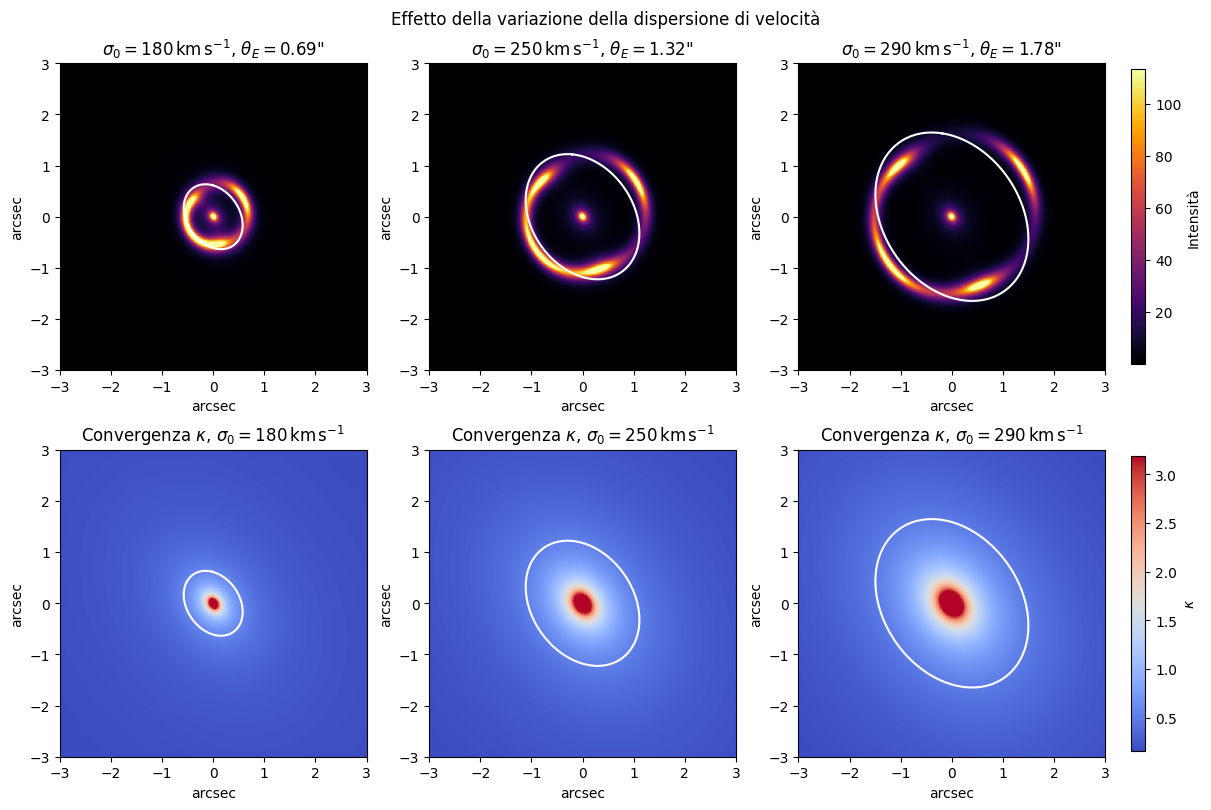

In [4]:
fig1, ax1 = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
fig1.suptitle("Effetto della variazione della dispersione di velocità")

vmax_image = max(
np.percentile(img[np.isfinite(img)], 99.5)
for img in total_images
)

vmax_kappa = max(
np.percentile(k[np.isfinite(k)], 99.5)
for k in kappa_maps
)

for i, sigma0 in enumerate(sigma0_values):
    im0 = ax1[0,i].imshow(total_images[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_image)
    ax1[0,i].set_xlabel("arcsec")
    ax1[0,i].set_ylabel("arcsec")

    im1 = ax1[1,i].imshow(kappa_maps[i], origin="lower", extent=extent, cmap="coolwarm", vmax=vmax_kappa)
    ax1[1,i].set_xlabel("arcsec")
    ax1[1,i].set_ylabel("arcsec")

    ax1[0,i].set_title(
    rf'$\sigma_0={sigma0}\,\mathrm{{km\,s^{{-1}}}}$, '
    rf'$\theta_E={einstein_radii[i]:.2f}$"')
    ax1[1,i].set_title(
    rf'Convergenza $\kappa$, $\sigma_0={sigma0}\,\mathrm{{km\,s^{{-1}}}}$')
    print(f"Raggio di Einstein per sigma_0={sigma0}: {einstein_radii[i]} arcsec")
    
for i in range(len(sigma0_values)):
    for xcrit, ycrit in critical_lines_all[i]:
        ax1[0,i].plot(xcrit, ycrit, color="white")
        ax1[1,i].plot(xcrit, ycrit, color="white")

for ax in ax1.flat:
    ax.set_aspect("equal")

cbar0 = fig1.colorbar(
    im0,
    ax=ax1[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Intensità")

cbar1 = fig1.colorbar(
    im1,
    ax=ax1[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label(r"$\kappa$")


## Salvataggio

In [5]:
figure_path = outdir / "final_simulations_sigma0.png"
fig1.savefig(figure_path, dpi=180)
print(f"Saved {figure_path}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_sigma0.png


# Disallineamento


## Define the SIE lens, define and lens the source, add lens-galaxy light
 

In [28]:
positions = ((0.01, 0.03), (0.15, 0.1), (-0.15,0.05), (0.3, 0.3))
total_images_2 = []
unlensed_images = []
critical_lines_all_2 = []
caustics_all =[]
einstein_radii_2 =np.zeros(len(positions))

for i, position in enumerate(positions):
 lens = sie(
     co,
     zl=zl, # redshift lente
     zs=zs, # redshift sorgente, più alto della lente 
     sigma0=220.0,
     q=0.75, # ellipticity
     pa=np.deg2rad(35.0), # angular position of the major ax
     theta_c=1.0e-4, # core radius, if 0 the profile becomes singular
     x1=0.0,
     x2=0.0,
 )
 lens.setGrid(theta=theta)
 
 critical_lines = [lens.getCritPoints(cl) for cl in lens.tancl()]
 einstein_radii_2[i] = lens.bsie()

 source_kwargs = {
    "n": 1.0,
    "re": 0.15,
    "q": 0.7,
    "pa": np.deg2rad(20.0),
    "ys1": position[0], # posizione sorgente, DA MODIFICARE
    "ys2": position[1], # posizione sorgente, DA MODIFICARE, 2-3 CASI 
    "flux": 1.0e4,
    "zs": zs,
}

 source = sersic(size=fov, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs) # Lensing of a Sersic source
 source_zoom = sersic(size=fov/6.0, Npix=npix, gl=lens, save_unlensed=True, **source_kwargs)
 unlensed_images.append(source.image_unlensed)
 caustics = lens.getCaustics(lens.tancl())

 lens_light_kwargs = {
    "n": 4.0,
    "re": 0.55,
    "q": 0.8,
    "pa": np.deg2rad(35.0),
    "ys1": 0.0,
    "ys2": 0.0,
    "flux": 3.0e4,
    "zs": zl,
 }

 lens_light = sersic(size=fov, Npix=npix, gl=None, **lens_light_kwargs) # adds the light of the lens galaxy, using a second Sersic profile 
#  total_image = source.image + lens_light.image
 source_image = source.image

 total_images_2.append(source_image.copy())

 critical_lines_all_2.append(critical_lines)
 caustics_all.append(caustics)


## Visualize the lensing configuration

Raggio di Einstein per position=(0.01, 0.03): 1.0241162086277753 arcsec
Raggio di Einstein per position=(0.15, 0.1): 1.0241162086277753 arcsec
Raggio di Einstein per position=(-0.15, 0.05): 1.0241162086277753 arcsec
Raggio di Einstein per position=(0.3, 0.3): 1.0241162086277753 arcsec


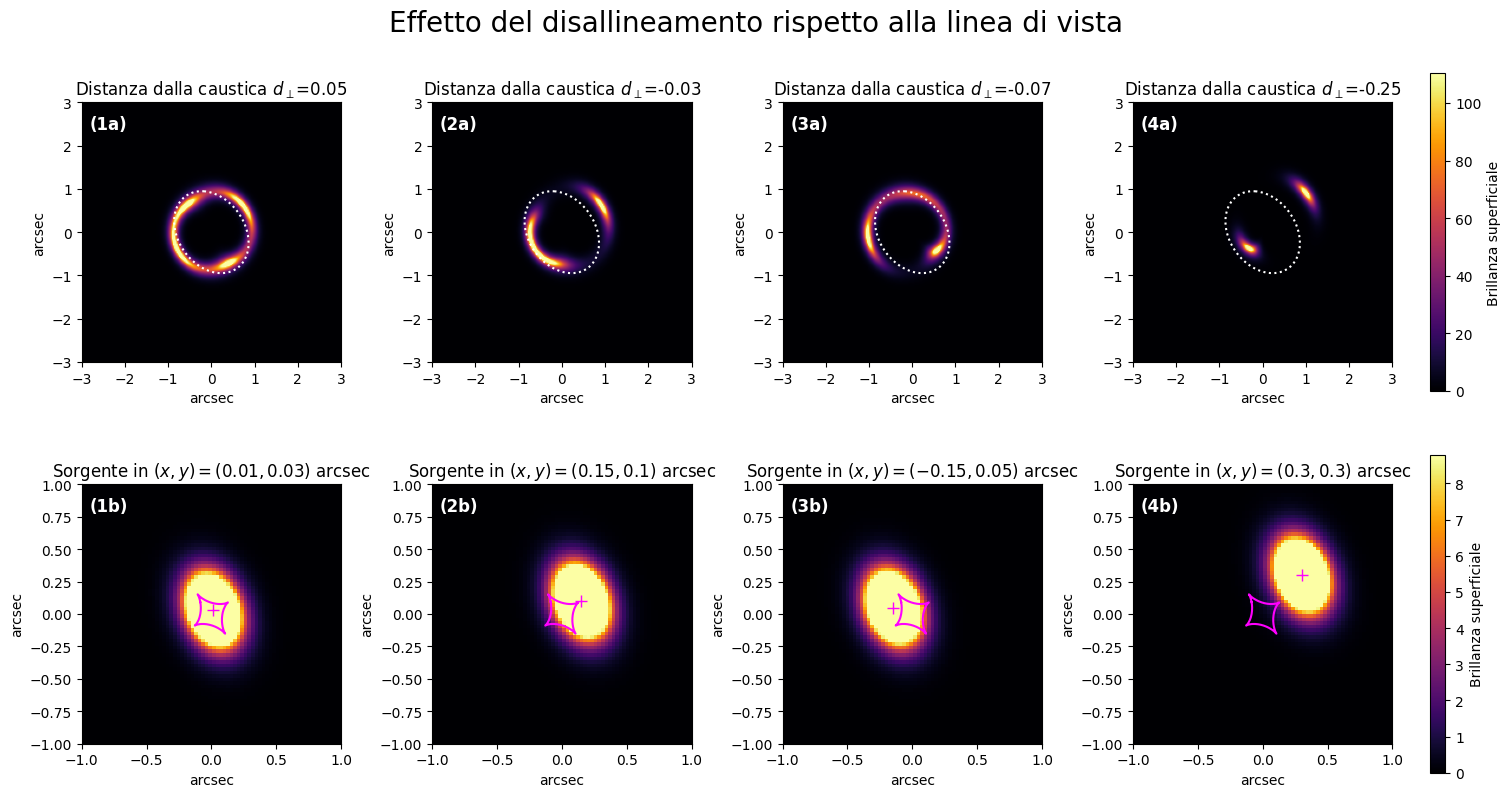

In [41]:
d_caustic_all = []

fig2, ax2 = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
fig2.suptitle("Effetto del disallineamento rispetto alla linea di vista", fontsize = 20)

vmax_image = max(
    np.percentile(img[np.isfinite(img)], 99.5)
    for img in total_images_2
)

vmax_unlensed = max(
    np.percentile(u[np.isfinite(u)], 99.5)
    for u in unlensed_images
)

for i in range(len(positions)):
    for xcrit, ycrit in critical_lines_all_2[i]:
            ax2[0,i].plot(xcrit, ycrit, color="white", linestyle= "dotted")
    
    position = np.array(positions[i])
    distances = []

    for cau in caustics_all[i]:
        xcau, ycau = lens.getCausticPoints(cau)
        # Disegna la caustica
        ax2[1, i].plot(xcau, ycau, color="magenta")
        # Coordinate dei punti della caustica
        caustic_points = np.column_stack((xcau, ycau))
        # Distanza della sorgente da ogni punto della caustica
        dists = np.linalg.norm(caustic_points - position, axis=1)
        # Punto della caustica più vicino alla sorgente
        j = np.argmin(dists)
        x0 = xcau[j]
        y0 = ycau[j]
        # Tangente locale alla caustica
        dx = np.gradient(xcau)
        dy = np.gradient(ycau)
        tangent = np.array([dx[j], dy[j]])
        # Normalizzazione della tangente
        tangent /= np.linalg.norm(tangent)
        # Normale alla caustica
        normal = np.array([-tangent[1], tangent[0]])
        # Vettore dal punto della caustica alla sorgente
        delta = position - np.array([x0, y0])
        # Distanza firmata lungo la normale
        d_normal = np.dot(delta, normal)
        distances.append(d_normal)
    # Distanza normale dalla caustica più vicina
    d_caustic = min(distances, key=abs)
    d_caustic_all.append(d_caustic)

for i, position in enumerate(positions):
    im0 = ax2[0,i].imshow(total_images_2[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_image)
    ax2[0,i].set_xlabel("arcsec")
    ax2[0,i].set_ylabel("arcsec")

    im1 = ax2[1,i].imshow(unlensed_images[i], origin="lower", extent=extent, cmap="inferno", vmax=vmax_unlensed)
    ax2[1,i].set_xlim(-1, 1)
    ax2[1,i].set_xlabel("arcsec")
    ax2[1,i].set_ylim(-1, 1)
    ax2[1,i].set_ylabel("arcsec")
    


    ax2[0,i].set_title(f'Distanza dalla caustica $d_\perp$={d_caustic_all[i]:.2f}')
    ax2[1,i].set_title(
    rf'Sorgente in $(x,y)={position}$ arcsec')
    ax2[1,i].plot(
    position[0],
    position[1],
    marker='+',
    color='magenta',
    markersize=8
)

    print(f"Raggio di Einstein per position={position}: {einstein_radii_2[i]} arcsec")


for ax in ax2.flat:
    ax.set_aspect("equal")

cbar0 = fig2.colorbar(
    im0,
    ax=ax2[0, :],
    shrink=0.85,
    pad=0.02
)
cbar0.set_label("Brillanza superficiale")

cbar1 = fig2.colorbar(
    im1,
    ax=ax2[1, :],
    shrink=0.85,
    pad=0.02
)
cbar1.set_label("Brillanza superficiale")

labels_a = ["(1a)", "(2a)", "(3a)", "(4a)"]
labels_b = ["(1b)", "(2b)", "(3b)", "(4b)"]

for i, lab in enumerate(labels_a):
    ax2[0,i].text(
        0.03, 0.95,
        lab,
        transform=ax2[0,i].transAxes,
        color="white",
        fontsize=12,
        fontweight="bold",
        va="top"
    )

for i, lab in enumerate(labels_b):
    ax2[1,i].text(
        0.03, 0.95,
        lab,
        transform=ax2[1,i].transAxes,
        color="white",
        fontsize=12,
        fontweight="bold",
        va="top"
    )


## Salvataggio

In [8]:
figure_path = outdir / "final_simulations_positions.png"
fig2.savefig(figure_path, dpi=180)
print(f"Saved {figure_path}")

Saved /home/sabrina-n/tesi-triennale/outputs/final_simulations_positions.png


## Test 1

In [38]:
print("max total_images_2 (no lens)=", np.max([np.nanmax(img) for img in total_images_2]))
print("max unlensed_images =", np.max([np.nanmax(img) for img in unlensed_images]))

print("lensed: ", np.max(source.image))
print("unlensed: ", np.max(source.image_unlensed))

print("source image: ", np.nanmax(source.image))
print("lens image: ", np.nanmax(lens_light.image))
print("total image: ", np.nanmax(total_image))


max total_images_2 (no lens)= 205.80200503299602
max unlensed_images = 200.5859721221491
lensed:  187.05552388364694
unlensed:  167.3762530939433
source image:  187.05552388364694
lens image:  309.44717226450143
total image:  309.456038466418


## Test 2

In [32]:
for i in range(len(total_images_2)):
    print(
        "lensed",
        np.max(total_images_2[i]),
        np.percentile(total_images_2[i], 99.5)
    )

    print(
        "unlensed",
        np.max(unlensed_images[i]),
        np.percentile(unlensed_images[i], 99.5)
    )

lensed 205.58716288678653 110.27507382645216
unlensed 180.28878765848054 8.38219861508474
lensed 205.80200503299602 90.09219312534897
unlensed 200.5859721221491 8.613026859854596
lensed 195.1329413180307 70.16000977881441
unlensed 188.8059121327078 8.39742434043863
lensed 187.05552388364694 43.2811554373767
unlensed 167.3762530939433 8.78014661659729


# Perturbatore SIE 